# 01 — Fitting a Prism Spectrum

This notebook demonstrates the basic `jwspecfit` workflow:
1. Load a JWST NIRSpec PRISM spectrum from FITS
2. Fit all observable emission lines (with bootstrap uncertainties by default)
3. Inspect per-line results (flux, SNR, EW)
4. Plot the fit with Gaussian components (in Angstroms)
5. Save/load fit results and export line measurements
6. Interactive plotly plot for zooming into line profiles
7. Fit a restricted wavelength window

The prism has wavelength-dependent resolution R(λ) ≈ 30–300, which
`jwspecfit` handles automatically from the FITS header.

In [1]:
import jwspecfit
import matplotlib.pyplot as plt

print(f"jwspecfit v{jwspecfit.__version__}")

jwspecfit v0.1.0


## Load the spectrum

The FITS file has a `SPEC1D` HDU with columns `wave` (µm), `flux` (µJy),
and `err` (µJy).  The grating is read from the header automatically.

In [2]:
spec = jwspecfit.read_fits("../../data/borg-v4_prism-clear_1747_732.spec.fits", z=8.22288)

print(f"Grating:    {spec.grating}")
print(f"Pixels:     {spec.n_pix}")
print(f"Wave range: {spec.wave_um.min():.3f} – {spec.wave_um.max():.3f} µm")

Grating:    PRISM
Pixels:     473
Wave range: 0.540 – 5.515 µm


## Quick look at the raw spectrum

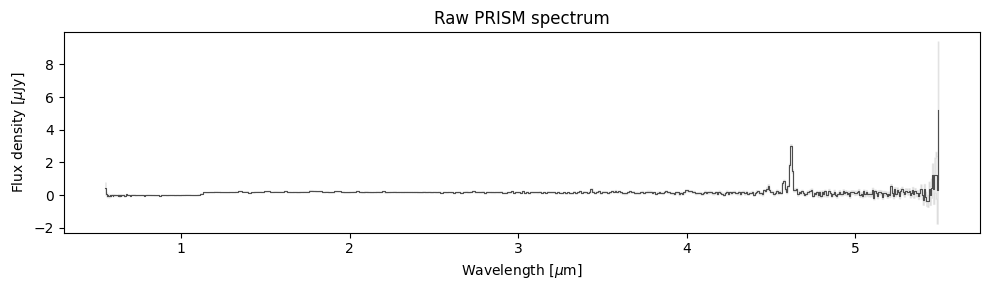

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
valid = spec.mask_valid()
ax.step(spec.wave_um[valid], spec.flux_ujy[valid], where="mid", lw=0.8, color="0.3")
ax.fill_between(
    spec.wave_um[valid],
    (spec.flux_ujy - spec.err_ujy)[valid],
    (spec.flux_ujy + spec.err_ujy)[valid],
    step="mid", alpha=0.15, color="0.5",
)
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"Flux density [$\mu$Jy]")
ax.set_title("Raw PRISM spectrum")
plt.tight_layout()

## Fit emission lines

A single call does everything: continuum subtraction, line detection,
Gaussian fitting, and bootstrap uncertainties.

Lines at or blueward of Lyman-α are automatically excluded (IGM-absorbed),
and the continuum is only fitted redward of the Lyman break.

In [8]:
result = jwspecfit.fit_lines(spec, z=8.22288, grating='PRISM',deg=4)

print(f"Fit success: {result.success}")
print(f"χ²/dof:      {result.chi2:.2f}")
print(f"Lines:       {', '.join(result.lines.keys())}")

Bootstrap: 100%|██████████| 1000/1000 [00:03<00:00, 266.70iter/s]

Fit success: True
χ²/dof:      1.83
Lines:       NV_doublet, CIV_doublet, CIII], OII_doublet, HDELTA, HGAMMA, OIII_4363, HBETA, OIII_4959, OIII_5007


## Per-line results

Each line has flux, bootstrap uncertainty, SNR, equivalent width,
centroid, and Gaussian width.

In [9]:
print(f"{'Line':<18s} {'Flux':>12s} {'Flux err':>12s} {'SNR':>8s} {'EW (Å)':>10s} {'σ (Å)':>8s}")
print("-" * 72)
for name, lr in result.lines.items():
    print(
        f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f} {lr.ew_A:10.1f} {lr.sigma_A:8.1f}"
    )

Line                       Flux     Flux err      SNR     EW (Å)    σ (Å)
------------------------------------------------------------------------
NV_doublet            8.760e-34    4.176e-27      0.0        0.0     37.6
CIV_doublet           1.341e-20    1.364e-18      0.0        0.1     84.4
CIII]                 1.408e-18    1.633e-18      0.9        7.9    105.9
OII_doublet           8.838e-19    5.246e-19      1.7       24.1     72.2
HDELTA                3.061e-19    4.511e-19      0.7       10.9     71.6
HGAMMA                6.540e-19    3.730e-19      1.8       28.5     75.8
OIII_4363             3.901e-19    3.470e-19      1.1       17.3     74.8
HBETA                 1.430e-18    4.668e-19      3.1      131.6     84.9
OIII_4959             2.485e-18    4.034e-19      6.2      304.1     87.7
OIII_5007             8.473e-18    4.231e-19     20.0     1224.5     87.4


## Plot the fit

The plot shows data, continuum, total model, and individual Gaussian
components as filled curves.  The y-axis is scaled to the tallest
emission line so the lines are clearly visible.

/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:241: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



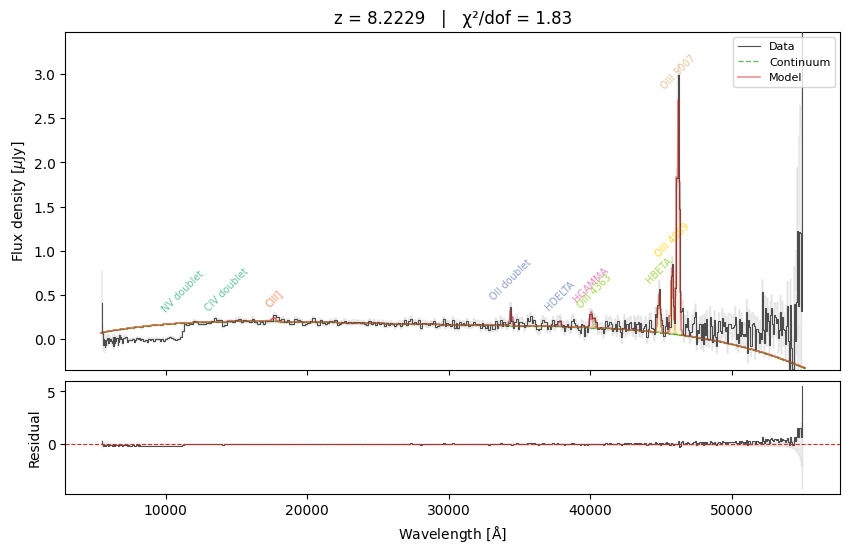

In [10]:
fig = jwspecfit.plot_fit(result)
plt.show()

In [11]:
fig_interactive = jwspecfit.plot_fit_interactive(result)
fig_interactive.show()

## Quick fit (analytic errors)

For fast exploration, set `n_boot=0` to skip bootstrap and use analytic
error estimates instead.

In [ ]:
result_fast = jwspecfit.fit_lines(spec, z=8.22288, n_boot=0)

print(f"{'Line':<18s} {'Flux':>12s} {'Err (analytic)':>14s} {'SNR':>8s}")
print("-" * 56)
for name, lr in result_fast.lines.items():
    if lr.snr > 2:
        print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:14.3e} {lr.snr:8.1f}")

## Fit specific lines only

You can restrict the fit to a subset of lines:

In [ ]:
result_oiii = jwspecfit.fit_lines(
    spec, z=8.22288,
    lines=["OIII_4959", "OIII_5007", "HBETA"],
)
fig = jwspecfit.plot_fit(result_oiii)
plt.show()

## Fit a wavelength window

Restrict the continuum and line fitting to a specific wavelength range
(in Angstroms). Useful for focusing on a single line complex.